<a href="https://colab.research.google.com/github/Govind243/Integrated-sensing-and-communication-VLC/blob/main/lisac3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Device-Free Visible Light Sensing (DF-VLS) — Monostatic / Reflection
  5 co-located LED-PD units on ceiling | 5x5x3 m room
  Channel: monostatic Eq.(4)  |  Detection: Delta-RSS Eq.(5)

[1/9] DFL positioning Monte Carlo (500 trials)...
      Monostatic median= 18.0 cm | 90th= 1.83 m
      + OIRS     median= 13.4 cm | 90th= 0.35 m
      done in 18.2s

[2/9] Room heatmaps (40x40 grid)...
      done in 37.5s

[3/9] Walking-target Delta-RSS signature...
      done in 0.0s

[4/9] Sensing coverage probability...
      done in 10.0s

[5/9] DFL error vs number of targets...
      targets=1 | monostatic= 55.3 cm | +OIRS= 20.0 cm
      targets=2 | monostatic= 64.9 cm | +OIRS= 18.7 cm
      targets=3 | monostatic= 57.1 cm | +OIRS= 19.1 cm
      targets=4 | monostatic= 62.4 cm | +OIRS= 20.5 cm
      targets=5 | monostatic= 57.8 cm | +OIRS= 19.7 cm
      targets=6 | monostatic= 57.0 cm | +OIRS= 19.6 cm
      targets=7 | monostatic= 58.3 cm | +OIRS= 25.0 cm
      targets=8 | monostatic= 64.9 cm | +

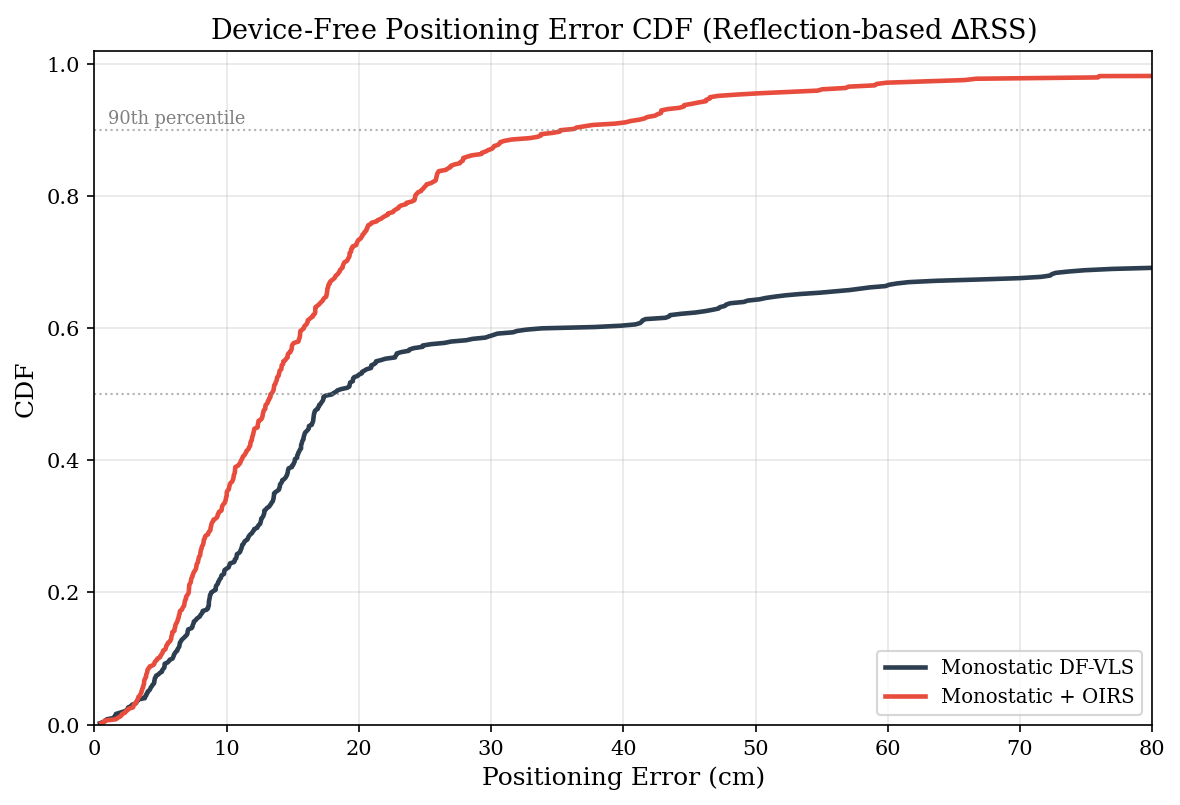

Saved P01_DFL_error_CDF.png


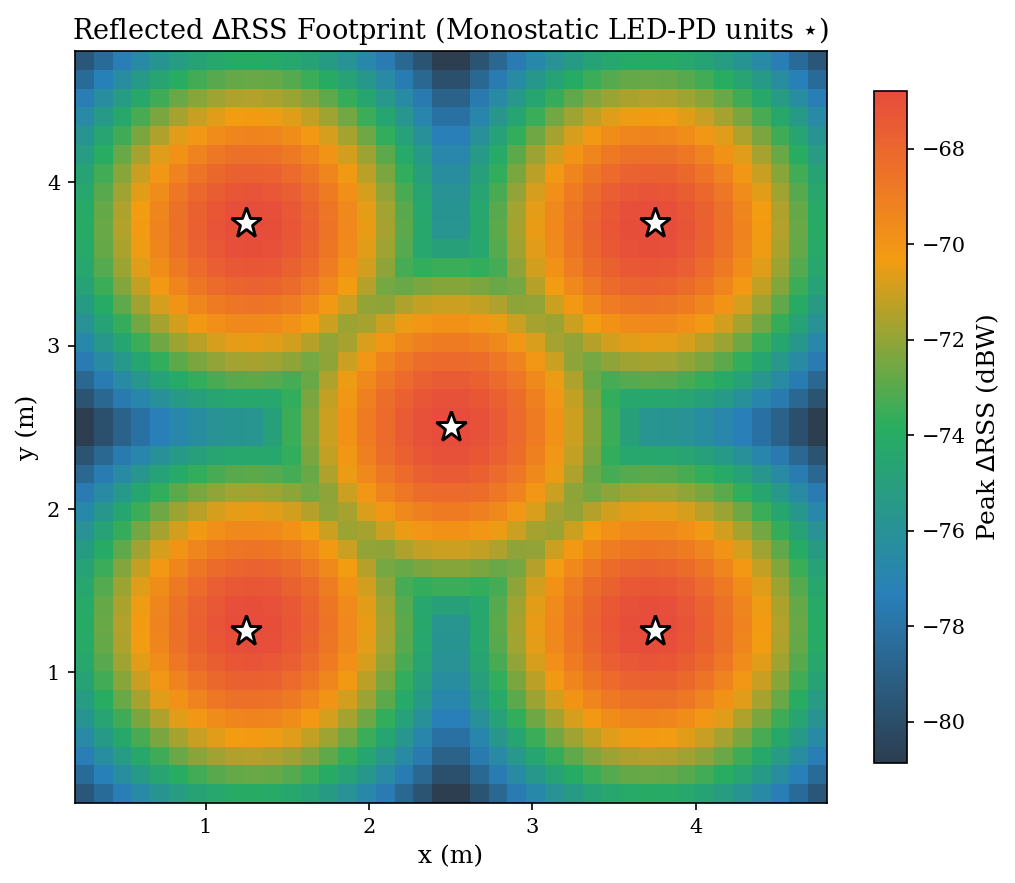

Saved P02_dRSS_heatmap.png


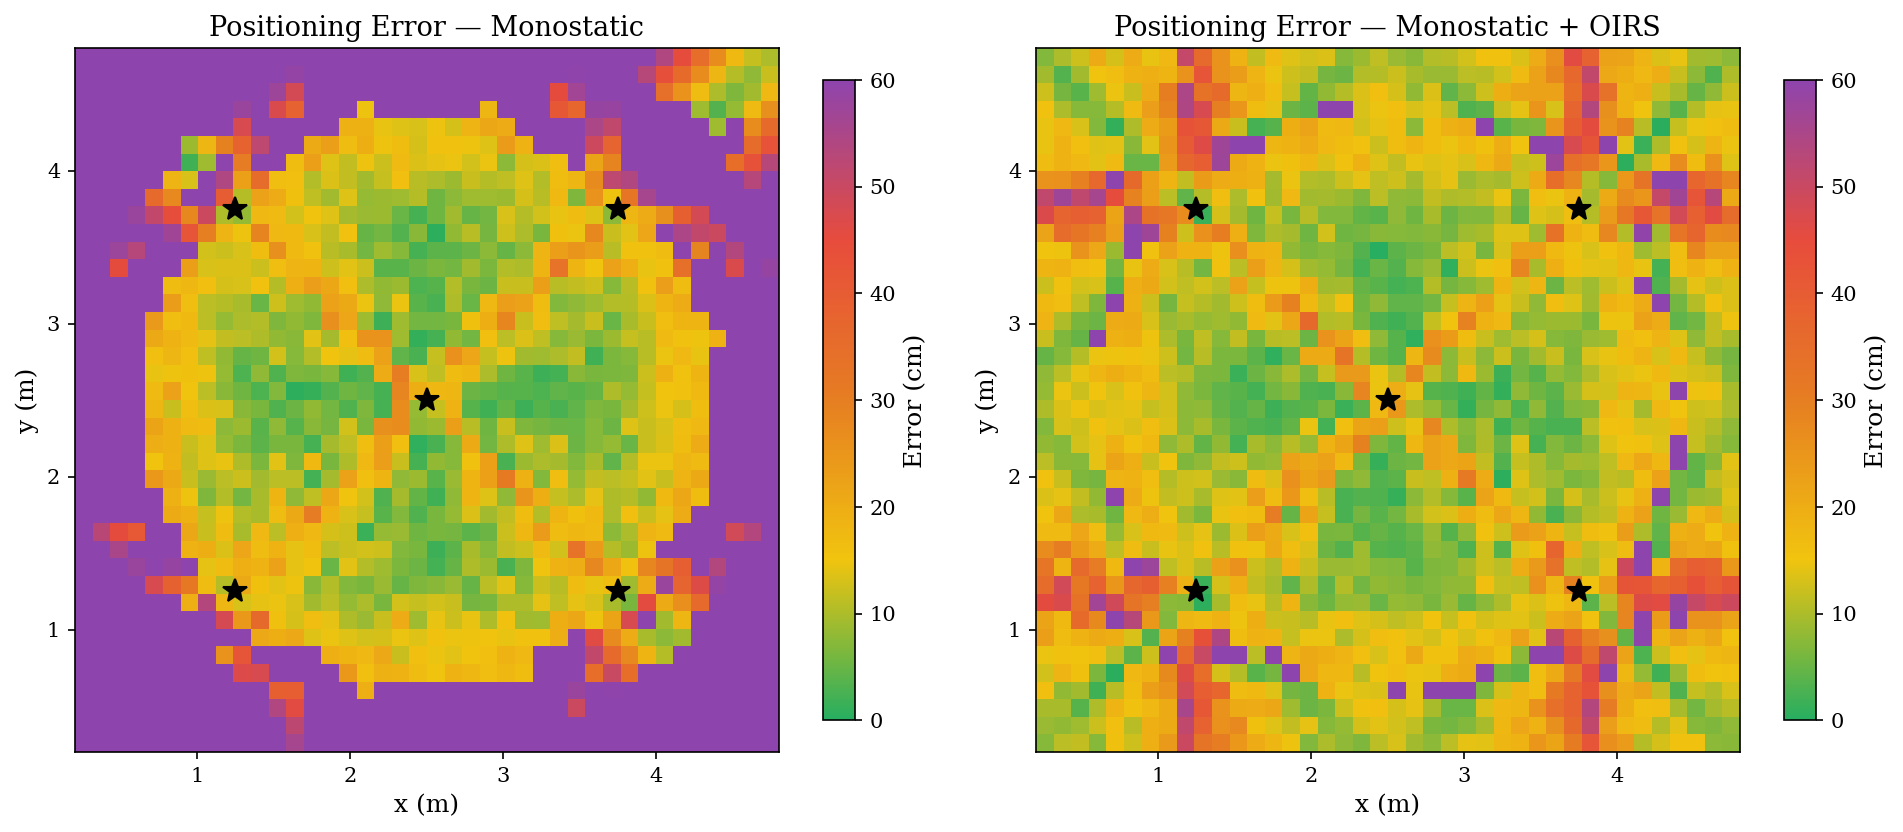

Saved P03_error_heatmap.png


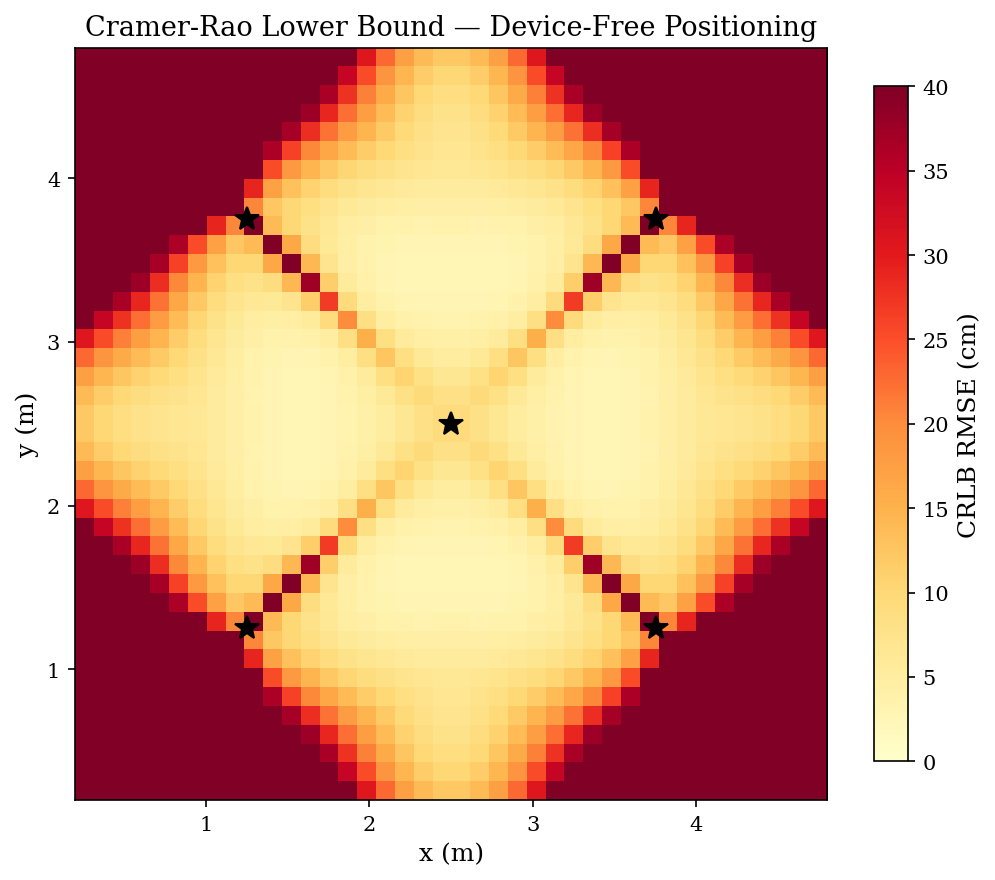

Saved P04_CRLB_heatmap.png


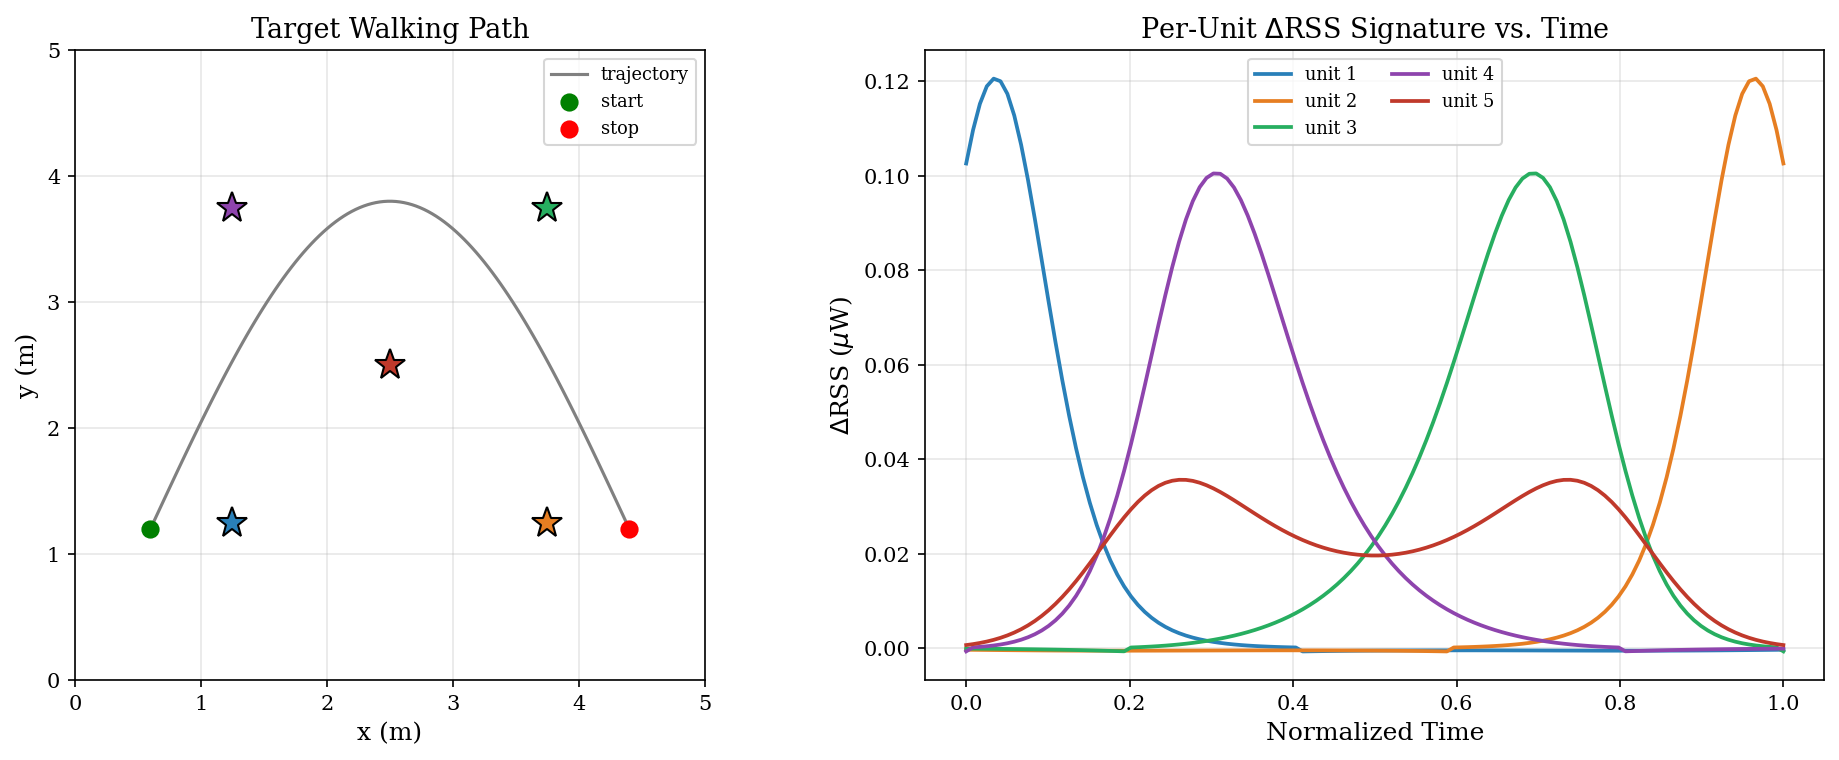

Saved P05_trajectory_dRSS.png


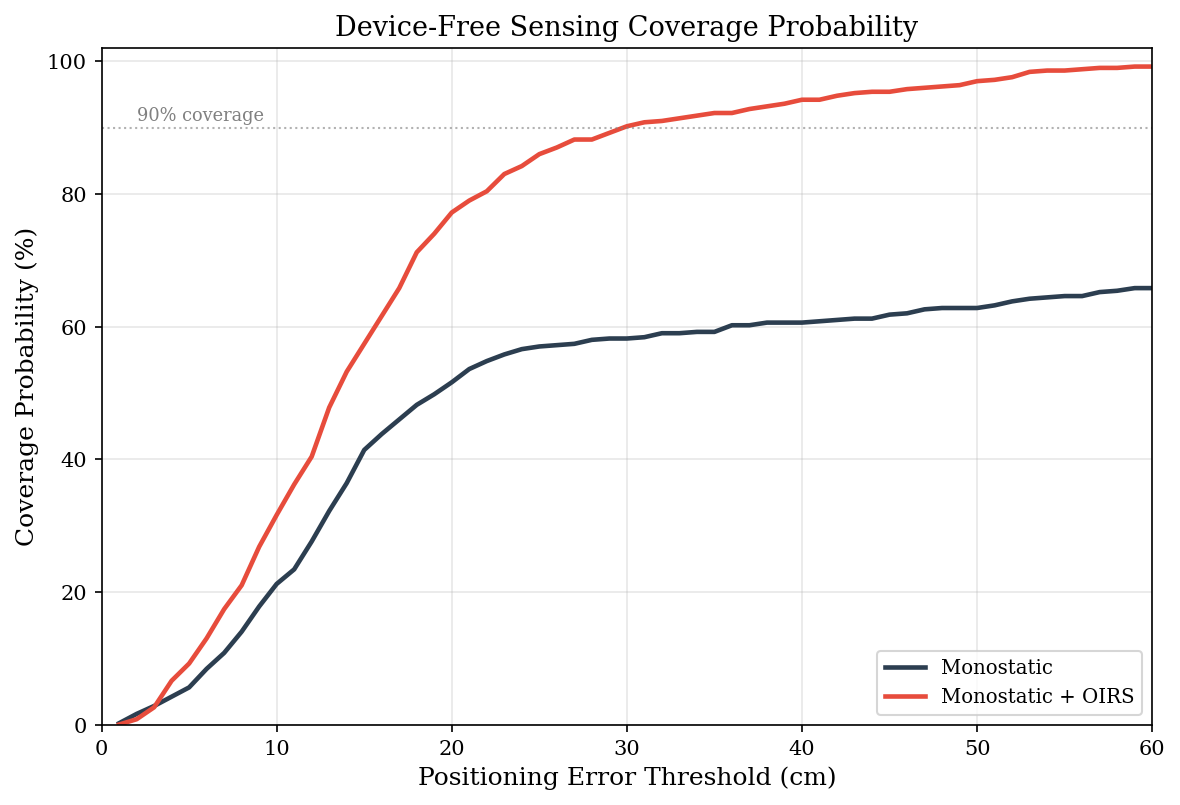

Saved P06_coverage.png


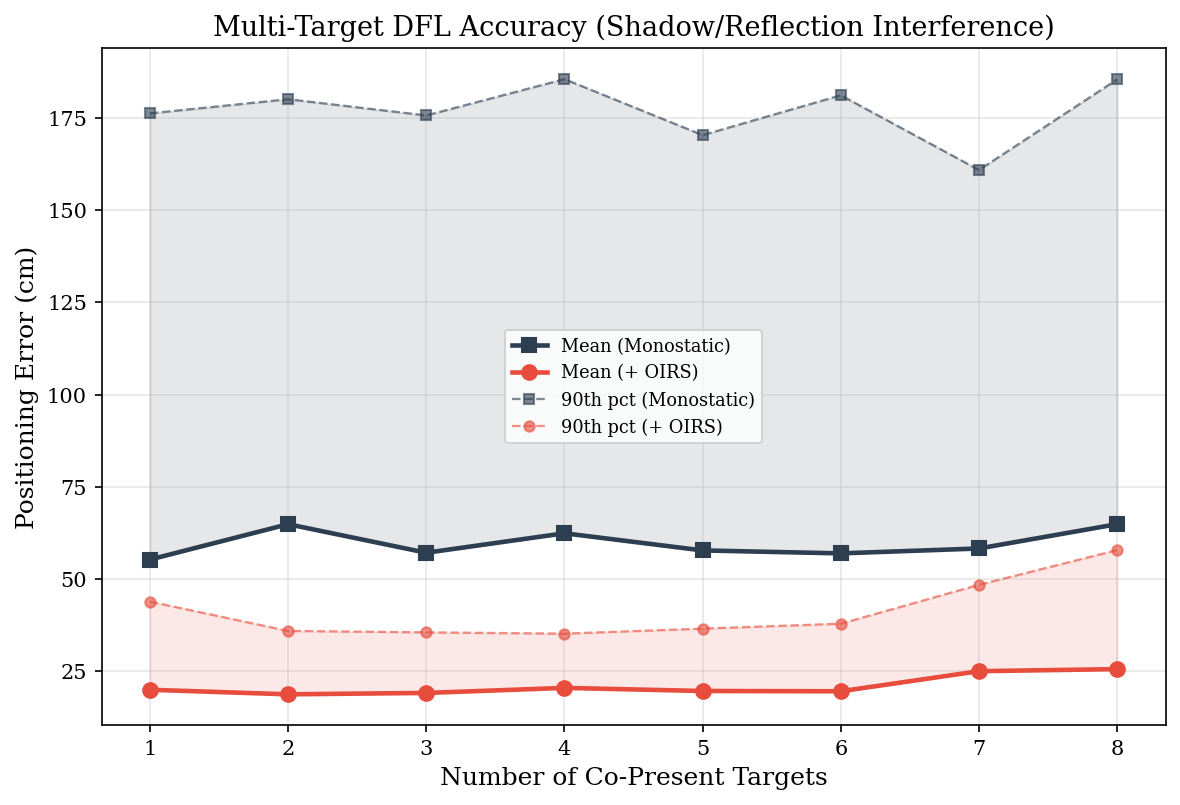

Saved P07_error_vs_targets.png


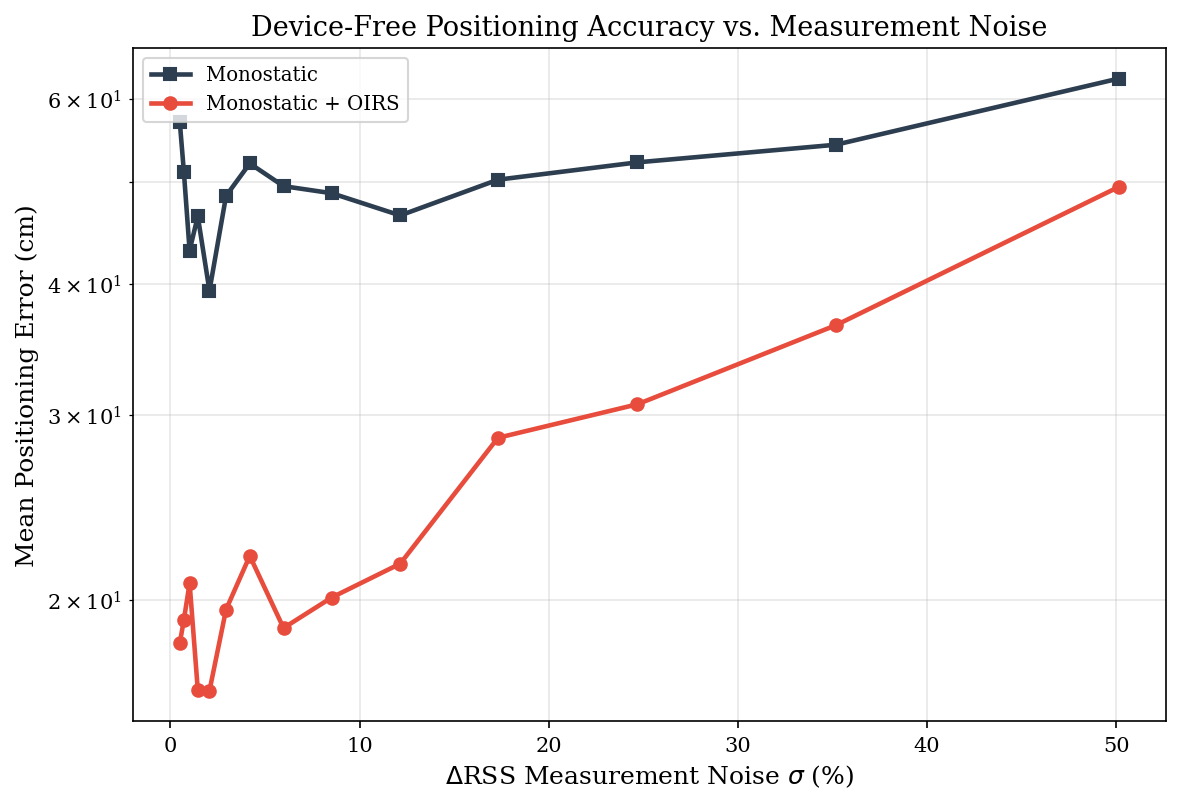

Saved P08_error_vs_noise.png


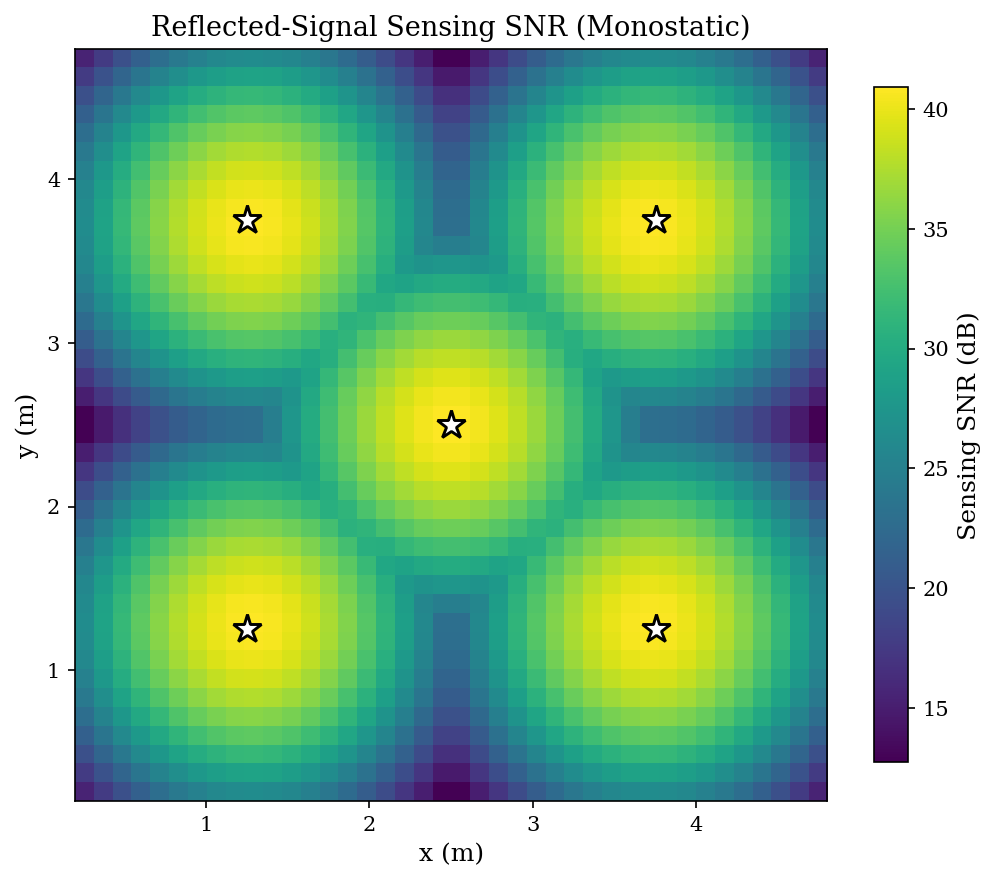

Saved P09_SNR_heatmap.png


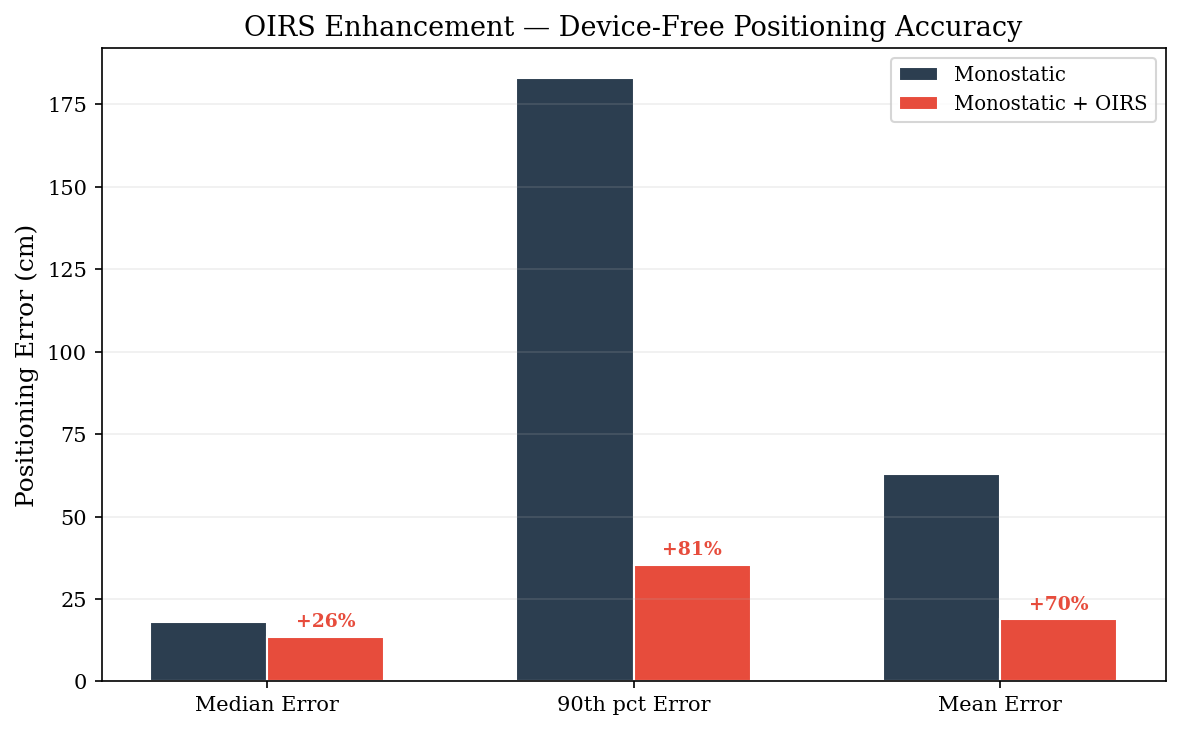

Saved P10_OIRS_gain.png


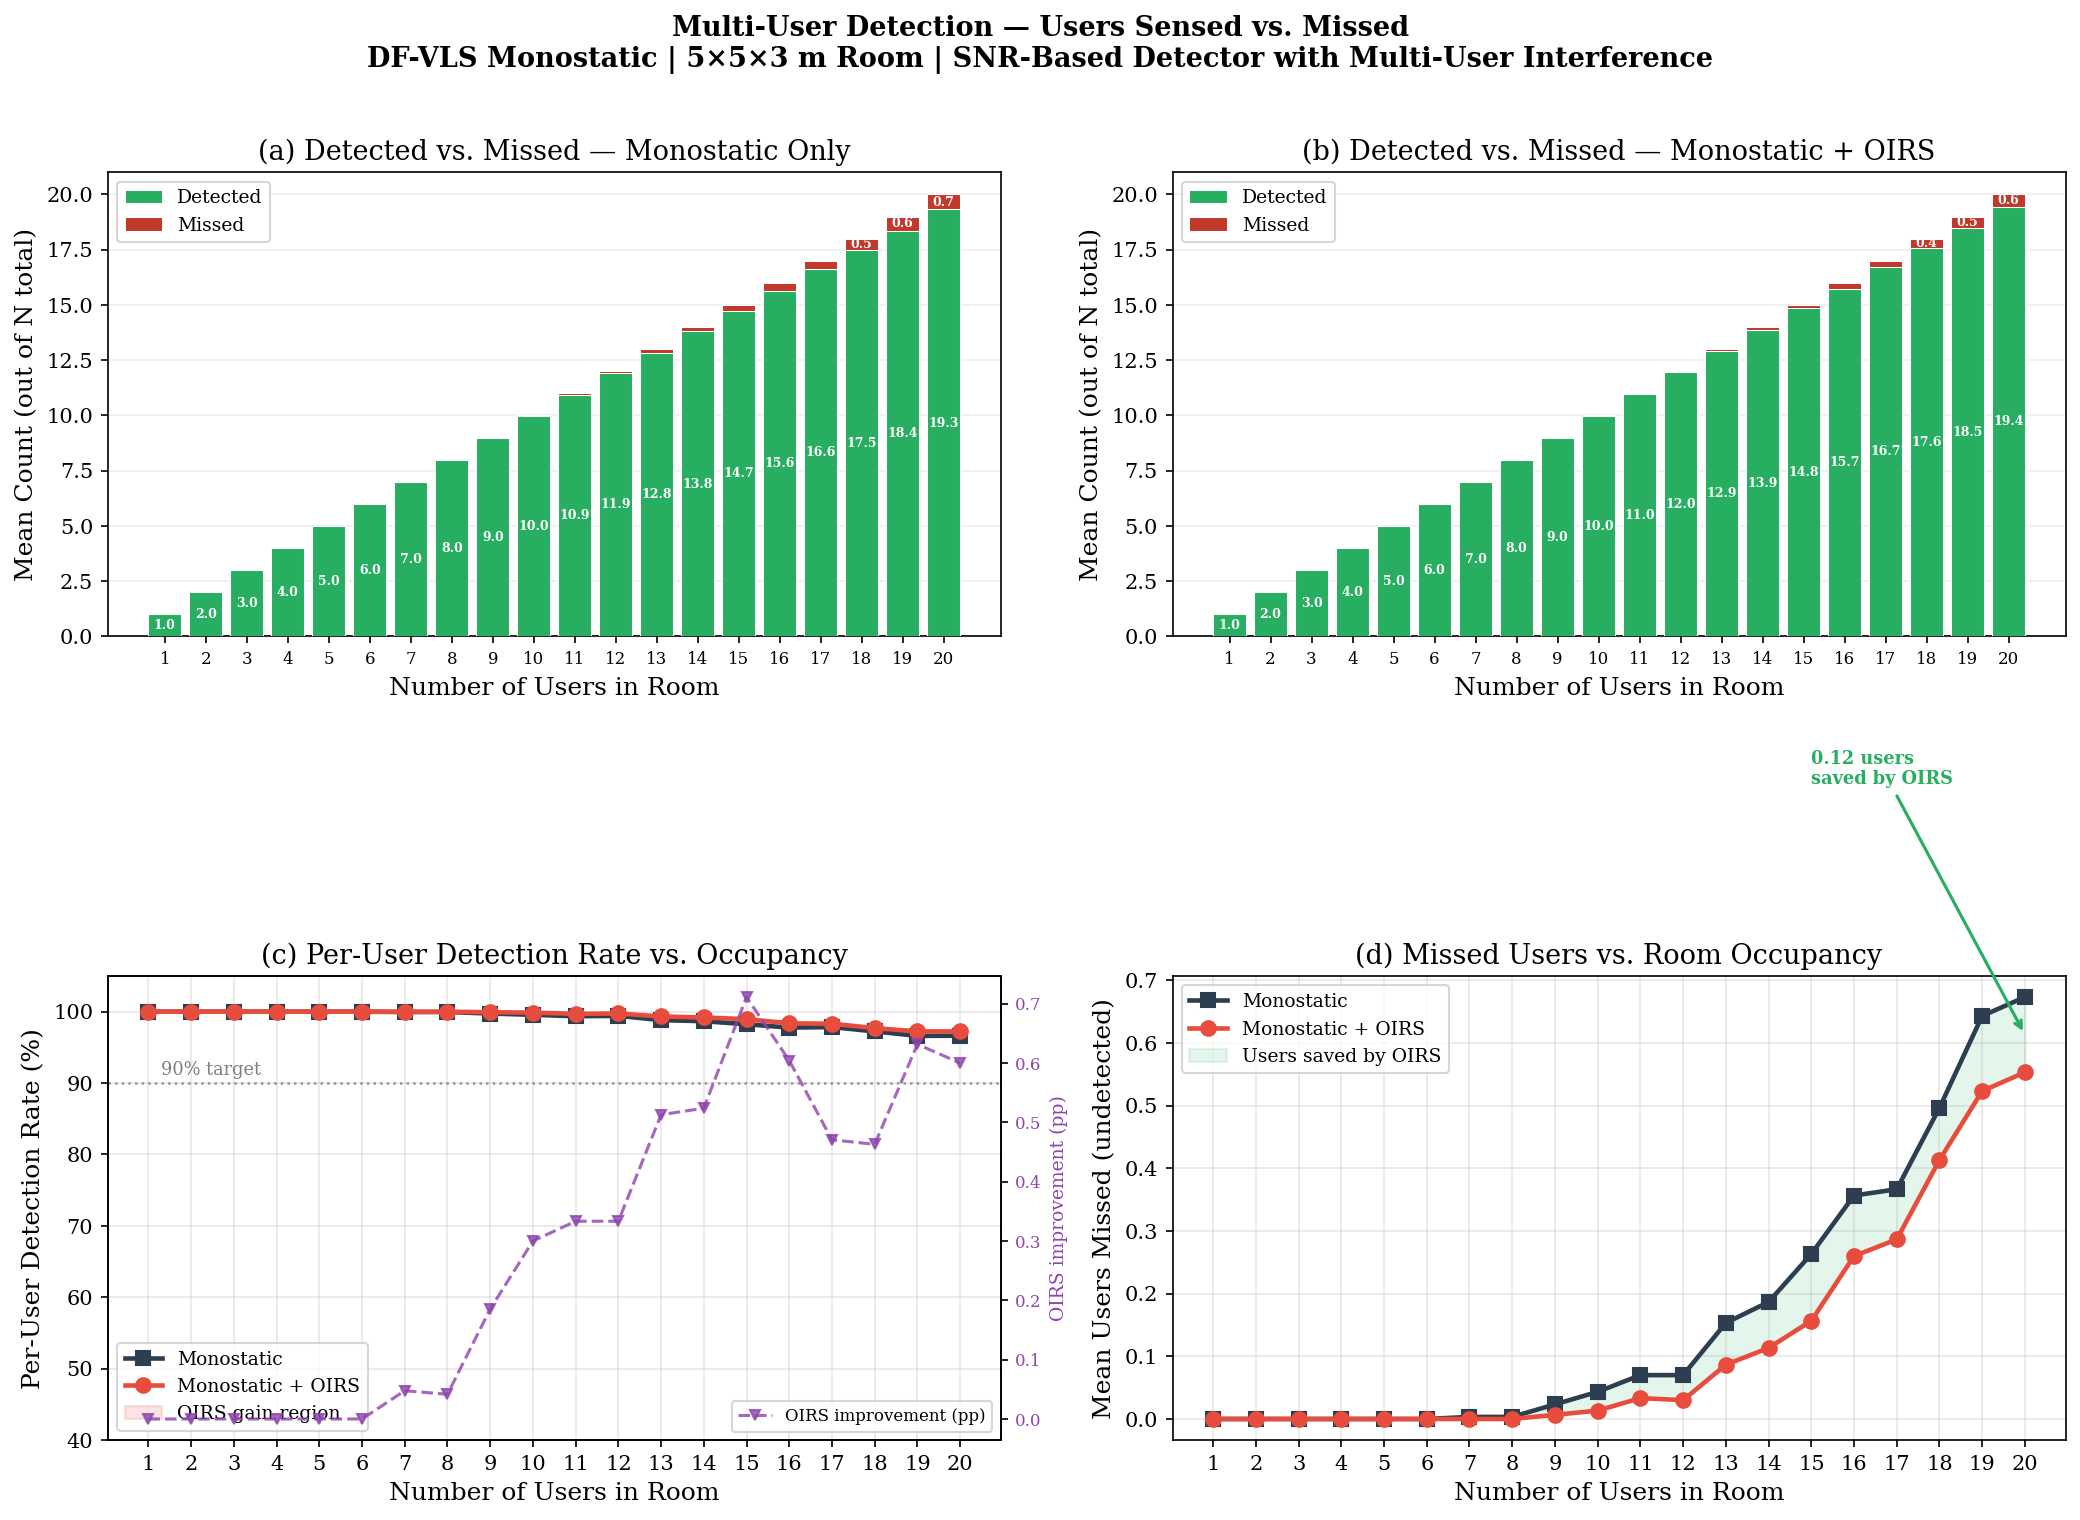

Saved P11_user_detection.png


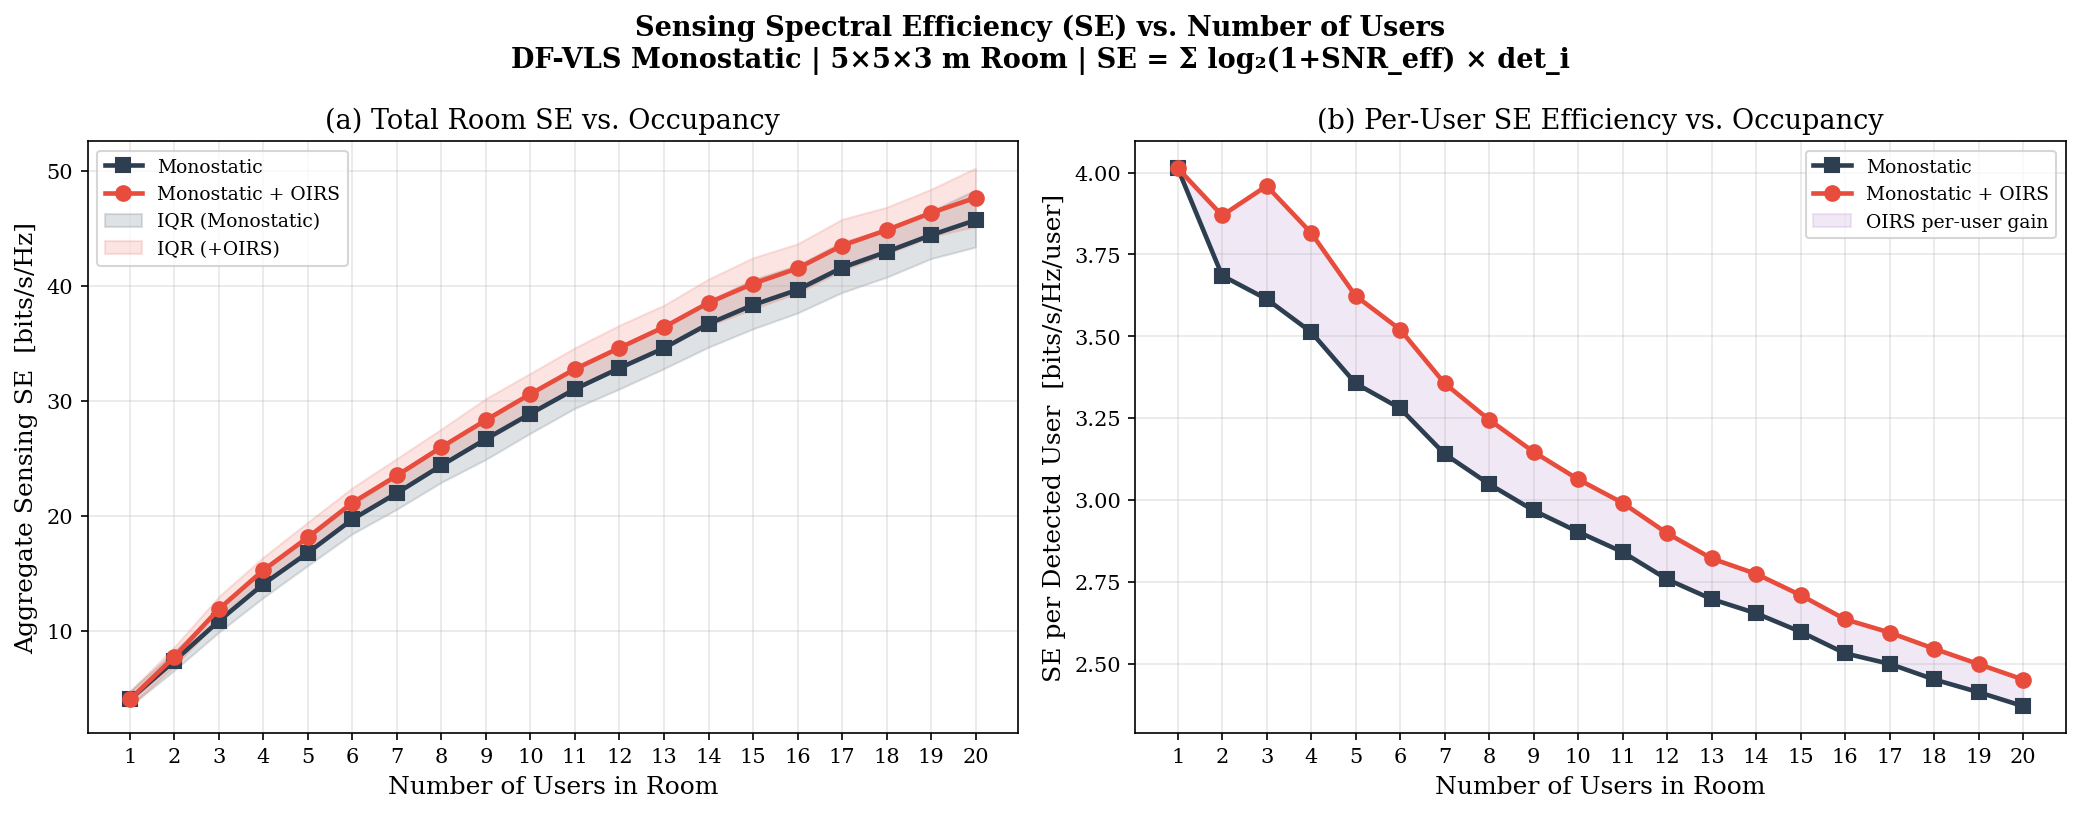

Saved P12_SE_vs_users.png

  Device-Free VLS (Monostatic, Reflection-based) — Results Summary
------------------------------------------------------------------------
  Metric                                     Monostatic         + OIRS
------------------------------------------------------------------------
  Median positioning error (cm)                   18.03          13.37
  90th pct positioning error (cm)                182.94          35.33
  Mean positioning error (cm)                     62.92          18.79
------------------------------------------------------------------------
  Multi-user detection (mean over all occupancies 1-20):
  Detection rate — Monostatic (%)                 98.99               
  Detection rate — +OIRS (%)                      99.28               
  Mean missed users — Monostatic                   0.17               
  Mean missed users — +OIRS                        0.12               
--------------------------------------------------------------

In [1]:
#!/usr/bin/env python3
"""
Device-Free Visible Light Sensing (DF-VLS) — Monostatic, Reflection-Based System
================================================================================
Reworked from the original device-based VLP code to match:

  M. Alijani, C. De Cock, W. Joseph, D. Plets,
  "Device-Free Visible Light Sensing: A Survey," IEEE COMST, 2025.

Key changes vs. the original (device-based) code
------------------------------------------------
  * DEVICE-FREE: the target (a human) carries NO receiver. It is a passive
    reflecting surface. Sensing is done from co-located ceiling LED-PD units.
  * MONOSTATIC channel model: Eq. (4) of the survey — Tx (LED) and Rx (PD)
    co-located, so the light path is  unit -> target surface -> same unit,
    decaying as 1/d^4 (vs. 1/d^2 for the old LOS link).
  * REFLECTION-BASED DETECTION via Delta-RSS, Eq. (5):  dRSS = RSS_wo - RSS_e
    (RSS with the object present minus the empty-room baseline). A person
    adds a strong, close reflection AND occludes the floor reflection it
    stands on, so dRSS is dominated by the person's position.
  * Device-free localization (DFL) by fitting the forward dRSS model.
  * Optical RIS / mirror enhancement kept as a roadmap item (Sec. VII-B3):
    mirrors extend the effective sensing range / SNR in poorly covered
    regions (far from units, near walls), improving DFL accuracy there.

Everything is VLS-only (no THz) to stay faithful to the survey.
Runs directly in Google Colab (plots show inline) or anywhere (saved to PNG).
"""

import numpy as np
import matplotlib
try:
    import google.colab  # noqa: F401  -> use default inline backend on Colab
except ImportError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import least_squares
import warnings, time, os
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# System Parameters
# ════════════════════════════════════════════════════════════════
room   = np.array([5.0, 5.0, 3.0])          # room [x, y, z] (m)
H_CEIL = room[2]

# ---- LED / PD optics ----
FOV       = 60.0                            # PD field-of-view semi-angle (deg)
psi_c     = np.deg2rad(FOV)
phi_half  = np.deg2rad(60.0)                # LED semi-angle at half power
m_k       = -np.log(2) / np.log(np.cos(phi_half))   # LED Lambertian order (~1)
m_d       = 1.0                             # diffuse target reflection order
Area_Pd   = 1e-4                            # PD active area A_R (m^2)
Resp_pd   = 0.53                            # PD responsivity (A/W)
n_refr    = 1.5                             # concentrator refractive index
Ts_filter = 1.0                             # optical filter gain  T_s(psi)
g_conc    = n_refr ** 2 / np.sin(psi_c) ** 2  # concentrator gain tau(psi)/g(psi)

# ---- electrical / noise ----
B           = 40e6                          # comm receiver bandwidth (Hz)
B_SENS      = 1e3                            # SENSING bandwidth (Hz)
q_charge    = 1.602e-19
PSD_thermal = 1e-21                         # thermal noise PSD (A^2/Hz)
RIN_lin     = 10 ** (-120.0 / 10.0)

# ---- Monostatic co-located LED-PD units on the ceiling ----
MONO_UNITS = np.array([
    [room[0] / 4,     room[1] / 4,     H_CEIL],
    [3 * room[0] / 4, room[1] / 4,     H_CEIL],
    [3 * room[0] / 4, 3 * room[1] / 4, H_CEIL],
    [room[0] / 4,     3 * room[1] / 4, H_CEIL],
    [room[0] / 2,     room[1] / 2,     H_CEIL],
])
N_UNITS = MONO_UNITS.shape[0]
P_total = 1.0
P_unit  = P_total / N_UNITS

# ---- Target (human) reflective model ----
H_PERSON   = 1.50
A_PERSON   = 0.30
RHO_PERSON = 0.60
RHO_FLOOR  = 0.30

# ---- Optical RIS / mirror array ----
NUM_MIRROR = 20
RHO_MIRROR = 0.95
D_REF_UNIT = 1.6

# ---- DELTA-RSS -> distance inversion ----
HGAP  = H_CEIL - H_PERSON
K_INV = (P_unit * (m_k + 1.0) * (m_d + 1.0) * Area_Pd / (4.0 * np.pi ** 2)
         * RHO_PERSON * A_PERSON * Ts_filter * g_conc)

# ---- simulation sizes ----
N_MONTE_CARLO  = 500
N_GRID_HEATMAP = 40
TARGET_COUNTS  = np.arange(1, 9)
SIGMA_RSS      = 0.05

# ---- Detection parameters ----
NOISE_FLOOR       = 5e-9
SNR_THRESHOLD     = 1.0
INTERF_RATIO      = 0.15
MULTI_USER_COUNTS = np.arange(1, 21)
N_DETECT_TRIALS   = 300

print("=" * 72)
print("  Device-Free Visible Light Sensing (DF-VLS) — Monostatic / Reflection")
print(f"  {N_UNITS} co-located LED-PD units on ceiling | 5x5x3 m room")
print("  Channel: monostatic Eq.(4)  |  Detection: Delta-RSS Eq.(5)")
print("=" * 72)


def monostatic_gain(unit, target, area, rho, m_diff=m_d):
    diff = unit - target
    d = np.linalg.norm(diff)
    if d < 1e-9:
        return 0.0
    cos_psi = diff[2] / d
    if cos_psi <= 0.0:
        return 0.0
    if np.arccos(np.clip(cos_psi, -1.0, 1.0)) > psi_c:
        return 0.0
    h = ((m_k + 1.0) * (m_diff + 1.0) * Area_Pd
         / (4.0 * np.pi ** 2 * d ** 4)) \
        * rho * area * cos_psi ** (m_k + 3.0) * Ts_filter * g_conc
    return h


def unit_drss(unit_pos, target_xy, loss=1.0):
    person = np.array([target_xy[0], target_xy[1], H_PERSON])
    floor  = np.array([target_xy[0], target_xy[1], 0.0])
    h_wo = monostatic_gain(unit_pos, person, A_PERSON, RHO_PERSON)
    h_e  = monostatic_gain(unit_pos, floor,  A_PERSON, RHO_FLOOR)
    return loss * P_unit * (h_wo - h_e)


def dRSS_vector(target_xy):
    return np.array([unit_drss(MONO_UNITS[k], target_xy) for k in range(N_UNITS)])


def _build_virtual_units():
    V = []
    for u in MONO_UNITS:
        V.append([u[0],              -u[1],             u[2]])
        V.append([u[0],  2 * room[1] - u[1],            u[2]])
        V.append([-u[0],              u[1],             u[2]])
        V.append([2 * room[0] - u[0], u[1],             u[2]])
    return np.array(V)


VIRT_UNITS = _build_virtual_units()
MIRROR_LOSS = RHO_MIRROR ** 2


def drss_to_distance(dr, loss=1.0):
    dr = max(dr, 1e-30)
    return (loss * K_INV * HGAP ** (m_k + 3.0) / dr) ** (1.0 / (m_k + 7.0))


def df_localize(target_xy_true, sigma_rss=SIGMA_RSS, use_oirs=False):
    if use_oirs:
        units3 = np.vstack([MONO_UNITS, VIRT_UNITS])
        losses = np.concatenate([np.ones(N_UNITS), np.full(len(VIRT_UNITS), MIRROR_LOSS)])
    else:
        units3 = MONO_UNITS.copy()
        losses = np.ones(N_UNITS)

    dR_true = np.array([unit_drss(units3[i], target_xy_true, losses[i]) for i in range(len(units3))])
    peak = max(np.max(dR_true), 1e-30)
    noise = sigma_rss * (np.abs(dR_true) + 0.02 * peak) * np.random.randn(len(dR_true))
    dR_meas = dR_true + noise

    order = np.argsort(dR_meas)[::-1]
    use = [i for i in order if dR_meas[i] > 0.06 * peak][:5]
    if len(use) < 3:
        use = list(order[:3])
    use = np.array(use)

    r_est = np.array([np.sqrt(max(drss_to_distance(max(dR_meas[i], 1e-30), losses[i]) ** 2 - HGAP ** 2, 0.0))
                      for i in use])
    w = np.clip(dR_meas[use], 1e-30, None)
    w = w / np.max(w)

    def residuals(xy):
        d = np.sqrt((xy[0] - units3[use, 0]) ** 2 + (xy[1] - units3[use, 1]) ** 2)
        return w * (d - r_est)

    x0 = np.average(units3[use, :2], axis=0, weights=w)
    x0 = np.clip(x0, [0.0, 0.0], [room[0], room[1]])
    res = least_squares(residuals, x0, method='trf',
                        bounds=([0.0, 0.0], [room[0], room[1]]))
    err = np.linalg.norm(res.x - np.asarray(target_xy_true))
    return res.x, err


def sensing_snr_db(target_xy, use_oirs=False):
    dR = list(np.abs(dRSS_vector(target_xy)))
    if use_oirs:
        dR += [abs(unit_drss(v, target_xy, MIRROR_LOSS)) for v in VIRT_UNITS]
    P_sig = max(np.max(dR), 1e-30)
    I = Resp_pd * P_sig
    s2 = PSD_thermal * B_SENS + 2 * q_charge * I * B_SENS + RIN_lin * I ** 2 * B_SENS
    snr = I ** 2 / max(s2, 1e-60)
    return 10 * np.log10(snr + 1e-12)


def crlb_df(target_xy, sigma_n=None):
    if sigma_n is None:
        sigma_n = np.sqrt(PSD_thermal * B_SENS) / Resp_pd
    grad = np.zeros((N_UNITS, 2))
    delta = 1e-3
    for dim in range(2):
        xp = list(target_xy); xp[dim] += delta
        xm = list(target_xy); xm[dim] -= delta
        grad[:, dim] = (dRSS_vector(xp) - dRSS_vector(xm)) / (2 * delta)
    FIM = (grad.T @ grad) / (sigma_n ** 2)
    try:
        return np.sqrt(max(np.trace(np.linalg.inv(FIM)), 0.0))
    except np.linalg.LinAlgError:
        return np.inf


def run_positioning_monte_carlo(n_trials=N_MONTE_CARLO, sigma_rss=SIGMA_RSS):
    print(f"\n[1/9] DFL positioning Monte Carlo ({n_trials} trials)...")
    t0 = time.time()
    e_base = np.zeros(n_trials)
    e_oirs = np.zeros(n_trials)
    for i in range(n_trials):
        x = np.random.uniform(0.3, room[0] - 0.3)
        y = np.random.uniform(0.3, room[1] - 0.3)
        _, e_base[i] = df_localize([x, y], sigma_rss, use_oirs=False)
        _, e_oirs[i] = df_localize([x, y], sigma_rss, use_oirs=True)
    print(f"      Monostatic median={np.median(e_base)*100:5.1f} cm | "
          f"90th={np.percentile(e_base,90):5.2f} m")
    print(f"      + OIRS     median={np.median(e_oirs)*100:5.1f} cm | "
          f"90th={np.percentile(e_oirs,90):5.2f} m")
    print(f"      done in {time.time()-t0:.1f}s")
    return e_base, e_oirs


def run_heatmaps(grid_n=N_GRID_HEATMAP):
    print(f"\n[2/9] Room heatmaps ({grid_n}x{grid_n} grid)...")
    t0 = time.time()
    xs = np.linspace(0.2, room[0] - 0.2, grid_n)
    ys = np.linspace(0.2, room[1] - 0.2, grid_n)
    drss_map = np.zeros((grid_n, grid_n))
    snr_map  = np.zeros((grid_n, grid_n))
    crlb_map = np.zeros((grid_n, grid_n))
    eb_map   = np.zeros((grid_n, grid_n))
    eo_map   = np.zeros((grid_n, grid_n))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            drss_map[i, j] = np.max(np.abs(dRSS_vector([x, y])))
            snr_map[i, j]  = sensing_snr_db([x, y])
            crlb_map[i, j] = crlb_df([x, y]) * 100.0
            _, eb_map[i, j] = df_localize([x, y], use_oirs=False)
            _, eo_map[i, j] = df_localize([x, y], use_oirs=True)
    drss_map = 10 * np.log10(drss_map + 1e-30)
    eb_map *= 100.0; eo_map *= 100.0
    print(f"      done in {time.time()-t0:.1f}s")
    return xs, ys, drss_map, snr_map, crlb_map, eb_map, eo_map


def run_trajectory():
    print(f"\n[3/9] Walking-target Delta-RSS signature...")
    t0 = time.time()
    t = np.linspace(0, 1, 120)
    path = np.column_stack([0.6 + 3.8 * t, 1.2 + 2.6 * np.sin(np.pi * t)])
    sig = np.zeros((len(t), N_UNITS))
    for i, (x, y) in enumerate(path):
        sig[i] = dRSS_vector([x, y]) * 1e6
    print(f"      done in {time.time()-t0:.1f}s")
    return t, path, sig


def run_coverage_probability():
    print(f"\n[4/9] Sensing coverage probability...")
    t0 = time.time()
    th_cm = np.linspace(1, 60, 60)
    n = 500
    eb = np.zeros(n); eo = np.zeros(n)
    for i in range(n):
        x = np.random.uniform(0.2, room[0] - 0.2)
        y = np.random.uniform(0.2, room[1] - 0.2)
        _, eb[i] = df_localize([x, y], use_oirs=False)
        _, eo[i] = df_localize([x, y], use_oirs=True)
    eb *= 100.0; eo *= 100.0
    cov_b = np.array([np.mean(eb < th) for th in th_cm])
    cov_o = np.array([np.mean(eo < th) for th in th_cm])
    print(f"      done in {time.time()-t0:.1f}s")
    return th_cm, cov_b, cov_o


def run_error_vs_targets():
    print(f"\n[5/9] DFL error vs number of targets...")
    t0 = time.time()
    n_trials = 200
    eb = np.zeros(len(TARGET_COUNTS)); eo = np.zeros(len(TARGET_COUNTS))
    eb90 = np.zeros(len(TARGET_COUNTS)); eo90 = np.zeros(len(TARGET_COUNTS))
    for idx, nt in enumerate(TARGET_COUNTS):
        lb, lo = [], []
        sigma_eff = SIGMA_RSS * np.sqrt(nt)
        for _ in range(n_trials):
            x = np.random.uniform(0.3, room[0] - 0.3)
            y = np.random.uniform(0.3, room[1] - 0.3)
            _, e1 = df_localize([x, y], sigma_eff, use_oirs=False)
            _, e2 = df_localize([x, y], sigma_eff, use_oirs=True)
            lb.append(e1); lo.append(e2)
        eb[idx], eo[idx] = np.mean(lb), np.mean(lo)
        eb90[idx], eo90[idx] = np.percentile(lb, 90), np.percentile(lo, 90)
        print(f"      targets={nt} | monostatic={eb[idx]*100:5.1f} cm | "
              f"+OIRS={eo[idx]*100:5.1f} cm")
    print(f"      done in {time.time()-t0:.1f}s")
    return eb, eo, eb90, eo90


def run_error_vs_noise():
    print(f"\n[6/9] DFL error vs Delta-RSS measurement noise...")
    t0 = time.time()
    sig_levels = np.logspace(-2.3, -0.3, 14)
    n_trials = 200
    eb = np.zeros(len(sig_levels)); eo = np.zeros(len(sig_levels))
    for si, s in enumerate(sig_levels):
        lb, lo = [], []
        for _ in range(n_trials):
            x = np.random.uniform(0.4, room[0] - 0.4)
            y = np.random.uniform(0.4, room[1] - 0.4)
            _, e1 = df_localize([x, y], s, use_oirs=False)
            _, e2 = df_localize([x, y], s, use_oirs=True)
            lb.append(e1); lo.append(e2)
        eb[si], eo[si] = np.mean(lb), np.mean(lo)
    print(f"      done in {time.time()-t0:.1f}s")
    return sig_levels, eb, eo


def run_joint():
    print(f"\n[7/9] Joint sensing SNR vs positioning accuracy...")
    t0 = time.time()
    n = 300
    snr = np.zeros(n); err = np.zeros(n)
    for i in range(n):
        x = np.random.uniform(0.3, room[0] - 0.3)
        y = np.random.uniform(0.3, room[1] - 0.3)
        snr[i] = sensing_snr_db([x, y], use_oirs=True)
        _, err[i] = df_localize([x, y], use_oirs=True)
    print(f"      done in {time.time()-t0:.1f}s")
    return snr, err * 100.0


def _detect_single_user(user_xy, n_others, use_oirs=False, sigma_rss=SIGMA_RSS):
    if use_oirs:
        units_all  = np.vstack([MONO_UNITS, VIRT_UNITS])
        losses_all = np.concatenate([np.ones(N_UNITS),
                                     np.full(len(VIRT_UNITS), MIRROR_LOSS)])
    else:
        units_all  = MONO_UNITS.copy()
        losses_all = np.ones(N_UNITS)

    peak_sig = max(
        np.max([unit_drss(units_all[k], user_xy, losses_all[k])
                for k in range(len(units_all))]),
        1e-30)

    snr_single = peak_sig / NOISE_FLOOR
    n_eff = max(n_others - 2, 0) if use_oirs else n_others
    snr_eff = snr_single / (1.0 + INTERF_RATIO * n_eff)
    snr_noisy = snr_eff * (1.0 + sigma_rss * np.random.randn())
    return snr_noisy >= SNR_THRESHOLD


def run_user_detection(n_users_list=MULTI_USER_COUNTS, n_trials=N_DETECT_TRIALS):
    print(f"\n[8/9] Multi-user detection simulation ({n_trials} trials per count)...")
    t0 = time.time()

    detected_base = np.zeros(len(n_users_list))
    detected_oirs = np.zeros(len(n_users_list))
    missed_base   = np.zeros(len(n_users_list))
    missed_oirs   = np.zeros(len(n_users_list))
    det_rate_base = np.zeros(len(n_users_list))
    det_rate_oirs = np.zeros(len(n_users_list))

    for idx, nu in enumerate(n_users_list):
        det_b_list, det_o_list = [], []
        for _ in range(n_trials):
            positions = [(np.random.uniform(0.3, room[0] - 0.3),
                          np.random.uniform(0.3, room[1] - 0.3))
                         for _ in range(nu)]
            det_b = 0; det_o = 0
            n_others = nu - 1
            for uxy in positions:
                if _detect_single_user(uxy, n_others, use_oirs=False):
                    det_b += 1
                if _detect_single_user(uxy, n_others, use_oirs=True):
                    det_o += 1
            det_b_list.append(det_b)
            det_o_list.append(det_o)

        detected_base[idx] = np.mean(det_b_list)
        detected_oirs[idx] = np.mean(det_o_list)
        missed_base[idx]   = nu - detected_base[idx]
        missed_oirs[idx]   = nu - detected_oirs[idx]
        det_rate_base[idx] = detected_base[idx] / nu
        det_rate_oirs[idx] = detected_oirs[idx] / nu

        print(f"      N={nu:2d} users | "
              f"detected(base)={detected_base[idx]:.1f}/{nu} "
              f"({det_rate_base[idx]*100:5.1f}%) | "
              f"detected(+OIRS)={detected_oirs[idx]:.1f}/{nu} "
              f"({det_rate_oirs[idx]*100:5.1f}%)")

    print(f"      done in {time.time()-t0:.1f}s")
    return (detected_base, detected_oirs,
            missed_base, missed_oirs,
            det_rate_base, det_rate_oirs)


# ════════════════════════════════════════════════════════════════
# [9/9] Sensing Spectral Efficiency (SE) vs. Number of Users — P12
# ════════════════════════════════════════════════════════════════
#
# For each user i in a room of N_u users, the effective per-user SNR is:
#
#     SNR_eff(i) = SNR_single(i) / (1 + INTERF_RATIO * n_eff)
#
# where n_eff = N_u - 1 for Monostatic, and max(N_u - 3, 0) for +OIRS
# (mirrors reduce effective interference per the detection model).
#
# Per-user sensing capacity (Shannon-like bound):
#
#     C_i = log2(1 + SNR_eff(i))    [bits/s/Hz]
#
# Aggregate Sensing Spectral Efficiency for the room:
#
#     SE_total = Σ_i [ C_i × det_i ]   (detected users only)
#
# SE per detected user measures individual-link quality degradation with load.
# ════════════════════════════════════════════════════════════════
N_SE_TRIALS = 400

def run_se_vs_users(n_users_list=MULTI_USER_COUNTS, n_trials=N_SE_TRIALS):
    print(f"\n[9/9] Sensing SE vs users ({n_trials} trials per occupancy)...")
    t0 = time.time()

    se_mean_b = np.zeros(len(n_users_list))
    se_mean_o = np.zeros(len(n_users_list))
    se_p25_b  = np.zeros(len(n_users_list))
    se_p25_o  = np.zeros(len(n_users_list))
    se_p75_b  = np.zeros(len(n_users_list))
    se_p75_o  = np.zeros(len(n_users_list))
    se_per_b  = np.zeros(len(n_users_list))
    se_per_o  = np.zeros(len(n_users_list))

    for idx, nu in enumerate(n_users_list):
        se_b_trials = []; se_o_trials = []
        det_b_sum = 0.0;  det_o_sum = 0.0

        for _ in range(n_trials):
            positions = [(np.random.uniform(0.3, room[0]-0.3),
                          np.random.uniform(0.3, room[1]-0.3))
                         for _ in range(nu)]
            n_others = nu - 1
            se_b = 0.0; se_o = 0.0; n_det_b = 0; n_det_o = 0

            for uxy in positions:
                # ── Monostatic ──────────────────────────────────────────
                peak_b = max(max(unit_drss(MONO_UNITS[k], uxy)
                                 for k in range(N_UNITS)), 1e-30)
                snr_s_b = peak_b / NOISE_FLOOR
                snr_e_b = snr_s_b / (1.0 + INTERF_RATIO * n_others)
                snr_n_b = snr_e_b * (1.0 + SIGMA_RSS * np.random.randn())
                det_b   = snr_n_b >= SNR_THRESHOLD
                se_b   += np.log2(1.0 + max(snr_e_b, 0.0)) * float(det_b)
                n_det_b += int(det_b)

                # ── Monostatic + OIRS ────────────────────────────────────
                units_o  = np.vstack([MONO_UNITS, VIRT_UNITS])
                losses_o = np.concatenate([np.ones(N_UNITS),
                                           np.full(len(VIRT_UNITS), MIRROR_LOSS)])
                peak_o = max(max(unit_drss(units_o[k], uxy, losses_o[k])
                                 for k in range(len(units_o))), 1e-30)
                snr_s_o  = peak_o / NOISE_FLOOR
                n_eff_o  = max(n_others - 2, 0)
                snr_e_o  = snr_s_o / (1.0 + INTERF_RATIO * n_eff_o)
                snr_n_o  = snr_e_o * (1.0 + SIGMA_RSS * np.random.randn())
                det_o    = snr_n_o >= SNR_THRESHOLD
                se_o    += np.log2(1.0 + max(snr_e_o, 0.0)) * float(det_o)
                n_det_o += int(det_o)

            se_b_trials.append(se_b); se_o_trials.append(se_o)
            det_b_sum += n_det_b;     det_o_sum += n_det_o

        se_b_arr = np.array(se_b_trials); se_o_arr = np.array(se_o_trials)
        se_mean_b[idx] = np.mean(se_b_arr);  se_mean_o[idx] = np.mean(se_o_arr)
        se_p25_b[idx]  = np.percentile(se_b_arr, 25)
        se_p25_o[idx]  = np.percentile(se_o_arr, 25)
        se_p75_b[idx]  = np.percentile(se_b_arr, 75)
        se_p75_o[idx]  = np.percentile(se_o_arr, 75)
        avg_det_b = det_b_sum / n_trials; avg_det_o = det_o_sum / n_trials
        se_per_b[idx] = se_mean_b[idx] / max(avg_det_b, 1e-9)
        se_per_o[idx] = se_mean_o[idx] / max(avg_det_o, 1e-9)

        print(f"      N={nu:2d} | SE_base={se_mean_b[idx]:6.2f} | "
              f"SE_oirs={se_mean_o[idx]:6.2f} bits/s/Hz")

    print(f"      done in {time.time()-t0:.1f}s")
    return (se_mean_b, se_mean_o,
            se_p25_b,  se_p25_o,
            se_p75_b,  se_p75_o,
            se_per_b,  se_per_o)


# ════════════════════════════════════════════════════════════════
# Run everything
# ════════════════════════════════════════════════════════════════
np.random.seed(42)
e_base_mc, e_oirs_mc = run_positioning_monte_carlo()
xs, ys, drss_map, snr_map, crlb_map, eb_map, eo_map = run_heatmaps()
t_traj, path_traj, sig_traj = run_trajectory()
th_cm, cov_b, cov_o = run_coverage_probability()
et_b, et_o, et_b90, et_o90 = run_error_vs_targets()
sig_levels, en_b, en_o = run_error_vs_noise()
snr_joint, err_joint = run_joint()
(det_base, det_oirs,
 mis_base, mis_oirs,
 rate_base, rate_oirs) = run_user_detection()
(se_mean_b, se_mean_o,
 se_p25_b,  se_p25_o,
 se_p75_b,  se_p75_o,
 se_per_b,  se_per_o) = run_se_vs_users()


# ════════════════════════════════════════════════════════════════
# Publication-quality plots
# ════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150, 'font.family': 'serif',
})
CLR_BASE = '#2c3e50'
CLR_OIRS = '#e74c3c'
CLR_CRLB = '#27ae60'
UNIT_CLRS = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad', '#c0392b']

out = './df_vls_plots'
os.makedirs(out, exist_ok=True)

# ── P1 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
for arr, lab, c in [(e_base_mc * 100, 'Monostatic DF-VLS', CLR_BASE),
                    (e_oirs_mc * 100, 'Monostatic + OIRS', CLR_OIRS)]:
    s = np.sort(arr); cdf = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, cdf, color=c, lw=2.2, label=lab)
ax.axhline(0.9, color='gray', ls=':', lw=1, alpha=0.6)
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.6)
ax.text(1, 0.91, '90th percentile', fontsize=8.5, color='gray')
ax.set_xlabel('Positioning Error (cm)'); ax.set_ylabel('CDF')
ax.set_title('Device-Free Positioning Error CDF (Reflection-based $\\Delta$RSS)')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim([0, min(80, np.percentile(e_base_mc * 100, 99))]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.savefig(f'{out}/P01_DFL_error_CDF.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P01_DFL_error_CDF.png")

# ── P2 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_d = LinearSegmentedColormap.from_list('d', ['#2c3e50', '#2980b9', '#27ae60', '#f39c12', '#e74c3c'])
im = ax.imshow(drss_map, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower',
               cmap=cm_d, aspect='equal')
ax.plot(MONO_UNITS[:, 0], MONO_UNITS[:, 1], 'w*', ms=15, mec='k', mew=1.4, zorder=5)
plt.colorbar(im, ax=ax, shrink=0.85, label='Peak $\\Delta$RSS (dBW)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Reflected $\\Delta$RSS Footprint (Monostatic LED-PD units $\\star$)')
plt.tight_layout(); plt.savefig(f'{out}/P02_dRSS_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P02_dRSS_heatmap.png")

# ── P3 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cm_e = LinearSegmentedColormap.from_list('e', ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad'])
for ax, data, title in zip(axes, [eb_map, eo_map],
                           ['Positioning Error — Monostatic', 'Positioning Error — Monostatic + OIRS']):
    vmax = min(np.percentile(eb_map, 95), 60)
    im = ax.imshow(data, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower',
                   cmap=cm_e, aspect='equal', vmin=0, vmax=vmax)
    ax.plot(MONO_UNITS[:, 0], MONO_UNITS[:, 1], 'k*', ms=12, mew=1)
    plt.colorbar(im, ax=ax, shrink=0.85, label='Error (cm)')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_title(title)
plt.tight_layout(); plt.savefig(f'{out}/P03_error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P03_error_heatmap.png")

# ── P4 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
vmax = min(np.percentile(crlb_map, 95), 40)
im = ax.imshow(crlb_map, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower',
               cmap='YlOrRd', aspect='equal', vmin=0, vmax=vmax)
ax.plot(MONO_UNITS[:, 0], MONO_UNITS[:, 1], 'k*', ms=12, mew=1)
plt.colorbar(im, ax=ax, shrink=0.85, label='CRLB RMSE (cm)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Cramer-Rao Lower Bound — Device-Free Positioning')
plt.tight_layout(); plt.savefig(f'{out}/P04_CRLB_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P04_CRLB_heatmap.png")

# ── P5 ─────────────────────────────────────────────────────────
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.2))
axA.plot(path_traj[:, 0], path_traj[:, 1], '-', color='gray', lw=1.5, label='trajectory')
axA.scatter(path_traj[0, 0], path_traj[0, 1], c='green', s=60, zorder=5, label='start')
axA.scatter(path_traj[-1, 0], path_traj[-1, 1], c='red', s=60, zorder=5, label='stop')
for k in range(N_UNITS):
    axA.plot(*MONO_UNITS[k, :2], '*', color=UNIT_CLRS[k], ms=15, mec='k', mew=1)
axA.set_xlim([0, room[0]]); axA.set_ylim([0, room[1]]); axA.set_aspect('equal')
axA.set_xlabel('x (m)'); axA.set_ylabel('y (m)'); axA.set_title('Target Walking Path')
axA.legend(loc='upper right', fontsize=8.5); axA.grid(True, alpha=0.3)
for k in range(N_UNITS):
    axB.plot(t_traj, sig_traj[:, k], color=UNIT_CLRS[k], lw=1.8, label=f'unit {k+1}')
axB.set_xlabel('Normalized Time'); axB.set_ylabel('$\\Delta$RSS ($\\mu$W)')
axB.set_title('Per-Unit $\\Delta$RSS Signature vs. Time'); axB.legend(ncol=2, fontsize=8.5)
axB.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{out}/P05_trajectory_dRSS.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P05_trajectory_dRSS.png")

# ── P6 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(th_cm, cov_b * 100, '-', color=CLR_BASE, lw=2.2, label='Monostatic')
ax.plot(th_cm, cov_o * 100, '-', color=CLR_OIRS, lw=2.2, label='Monostatic + OIRS')
ax.axhline(90, color='gray', ls=':', lw=1, alpha=0.6); ax.text(2, 91, '90% coverage', fontsize=8.5, color='gray')
ax.set_xlabel('Positioning Error Threshold (cm)'); ax.set_ylabel('Coverage Probability (%)')
ax.set_title('Device-Free Sensing Coverage Probability')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim([0, 60]); ax.set_ylim([0, 102])
plt.tight_layout(); plt.savefig(f'{out}/P06_coverage.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P06_coverage.png")

# ── P7 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(TARGET_COUNTS, et_b * 100, 's-', color=CLR_BASE, lw=2.2, ms=7, label='Mean (Monostatic)')
ax.plot(TARGET_COUNTS, et_o * 100, 'o-', color=CLR_OIRS, lw=2.2, ms=7, label='Mean (+ OIRS)')
ax.fill_between(TARGET_COUNTS, et_b * 100, et_b90 * 100, alpha=0.12, color=CLR_BASE)
ax.fill_between(TARGET_COUNTS, et_o * 100, et_o90 * 100, alpha=0.12, color=CLR_OIRS)
ax.plot(TARGET_COUNTS, et_b90 * 100, 's--', color=CLR_BASE, lw=1.1, ms=5, alpha=0.6, label='90th pct (Monostatic)')
ax.plot(TARGET_COUNTS, et_o90 * 100, 'o--', color=CLR_OIRS, lw=1.1, ms=5, alpha=0.6, label='90th pct (+ OIRS)')
ax.set_xlabel('Number of Co-Present Targets'); ax.set_ylabel('Positioning Error (cm)')
ax.set_title('Multi-Target DFL Accuracy (Shadow/Reflection Interference)')
ax.set_xticks(TARGET_COUNTS); ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{out}/P07_error_vs_targets.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P07_error_vs_targets.png")

# ── P8 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.semilogy(sig_levels * 100, en_b * 100, 's-', color=CLR_BASE, lw=2.2, ms=6, label='Monostatic')
ax.semilogy(sig_levels * 100, en_o * 100, 'o-', color=CLR_OIRS, lw=2.2, ms=6, label='Monostatic + OIRS')
ax.set_xlabel('$\\Delta$RSS Measurement Noise $\\sigma$ (%)'); ax.set_ylabel('Mean Positioning Error (cm)')
ax.set_title('Device-Free Positioning Accuracy vs. Measurement Noise')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.savefig(f'{out}/P08_error_vs_noise.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P08_error_vs_noise.png")

# ── P9 ─────────────────────────────────────────────────────────
snr_grid = np.zeros((N_GRID_HEATMAP, N_GRID_HEATMAP))
for i, y in enumerate(ys):
    for j, x in enumerate(xs):
        snr_grid[i, j] = sensing_snr_db([x, y])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(snr_grid, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower',
               cmap='viridis', aspect='equal')
ax.plot(MONO_UNITS[:, 0], MONO_UNITS[:, 1], 'w*', ms=14, mec='k', mew=1.4, zorder=5)
plt.colorbar(im, ax=ax, shrink=0.85, label='Sensing SNR (dB)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Reflected-Signal Sensing SNR (Monostatic)')
plt.tight_layout(); plt.savefig(f'{out}/P09_SNR_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P09_SNR_heatmap.png")

# ── P10 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metrics = {
    'Median Error':  [np.median(e_base_mc) * 100, np.median(e_oirs_mc) * 100],
    '90th pct Error':[np.percentile(e_base_mc, 90) * 100, np.percentile(e_oirs_mc, 90) * 100],
    'Mean Error':    [np.mean(e_base_mc) * 100, np.mean(e_oirs_mc) * 100],
}
xp = np.arange(len(metrics)); w = 0.32
ax.bar(xp - w / 2, [v[0] for v in metrics.values()], w, color=CLR_BASE, label='Monostatic', edgecolor='white')
ax.bar(xp + w / 2, [v[1] for v in metrics.values()], w, color=CLR_OIRS, label='Monostatic + OIRS', edgecolor='white')
ax.set_xticks(xp); ax.set_xticklabels(metrics.keys()); ax.set_ylabel('Positioning Error (cm)')
ax.set_title('OIRS Enhancement — Device-Free Positioning Accuracy'); ax.legend()
for i, (k, v) in enumerate(metrics.items()):
    if v[0] > 0:
        ax.annotate(f'{(v[0]-v[1])/v[0]*100:+.0f}%', xy=(i + w / 2, v[1]),
                    xytext=(0, 5), textcoords='offset points', ha='center',
                    fontsize=9, color=CLR_OIRS, fontweight='bold')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.savefig(f'{out}/P10_OIRS_gain.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P10_OIRS_gain.png")

# ── P11 ────────────────────────────────────────────────────────
CLR_DET  = '#27ae60'
CLR_MIS  = '#c0392b'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-User Detection — Users Sensed vs. Missed\n'
             'DF-VLS Monostatic | 5\u00d75\u00d73 m Room | SNR-Based Detector with Multi-User Interference',
             fontsize=13, fontweight='bold', y=1.01)
x_pos = np.arange(len(MULTI_USER_COUNTS))

ax = axes[0, 0]
ax.bar(x_pos, det_base, color=CLR_DET, edgecolor='white', lw=0.5, label='Detected', zorder=3)
ax.bar(x_pos, mis_base, bottom=det_base, color=CLR_MIS, edgecolor='white', lw=0.5, label='Missed', zorder=3)
for xi, (d, m) in enumerate(zip(det_base, mis_base)):
    if d > 0.4: ax.text(xi, d/2, f'{d:.1f}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
    if m > 0.4: ax.text(xi, d+m/2, f'{m:.1f}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(MULTI_USER_COUNTS, fontsize=8)
ax.set_xlabel('Number of Users in Room'); ax.set_ylabel('Mean Count (out of N total)')
ax.set_title('(a) Detected vs. Missed — Monostatic Only')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.2, axis='y', zorder=0)

ax = axes[0, 1]
ax.bar(x_pos, det_oirs, color=CLR_DET, edgecolor='white', lw=0.5, label='Detected', zorder=3)
ax.bar(x_pos, mis_oirs, bottom=det_oirs, color=CLR_MIS, edgecolor='white', lw=0.5, label='Missed', zorder=3)
for xi, (d, m) in enumerate(zip(det_oirs, mis_oirs)):
    if d > 0.4: ax.text(xi, d/2, f'{d:.1f}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
    if m > 0.4: ax.text(xi, d+m/2, f'{m:.1f}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(MULTI_USER_COUNTS, fontsize=8)
ax.set_xlabel('Number of Users in Room'); ax.set_ylabel('Mean Count (out of N total)')
ax.set_title('(b) Detected vs. Missed — Monostatic + OIRS')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.2, axis='y', zorder=0)

ax = axes[1, 0]
ax.plot(MULTI_USER_COUNTS, rate_base * 100, 's-', color=CLR_BASE, lw=2.2, ms=7, label='Monostatic')
ax.plot(MULTI_USER_COUNTS, rate_oirs * 100, 'o-', color=CLR_OIRS, lw=2.2, ms=7, label='Monostatic + OIRS')
ax.fill_between(MULTI_USER_COUNTS, rate_base * 100, rate_oirs * 100, alpha=0.15, color=CLR_OIRS, label='OIRS gain region')
ax.axhline(90, color='gray', ls=':', lw=1.2, alpha=0.8)
ax.text(1.3, 91.2, '90% target', fontsize=8.5, color='gray')
ax.set_xlabel('Number of Users in Room'); ax.set_ylabel('Per-User Detection Rate (%)')
ax.set_title('(c) Per-User Detection Rate vs. Occupancy')
ax.set_ylim([40, 105]); ax.set_xticks(MULTI_USER_COUNTS)
ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(MULTI_USER_COUNTS, (rate_oirs - rate_base) * 100, 'v--', color='#8e44ad', lw=1.5, ms=5, alpha=0.8, label='OIRS improvement (pp)')
ax2.set_ylabel('OIRS improvement (pp)', color='#8e44ad', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#8e44ad', labelsize=8)
ax2.legend(loc='lower right', fontsize=8)

ax = axes[1, 1]
ax.plot(MULTI_USER_COUNTS, mis_base, 's-', color=CLR_BASE, lw=2.2, ms=7, label='Monostatic')
ax.plot(MULTI_USER_COUNTS, mis_oirs, 'o-', color=CLR_OIRS, lw=2.2, ms=7, label='Monostatic + OIRS')
ax.fill_between(MULTI_USER_COUNTS, mis_oirs, mis_base, alpha=0.12, color=CLR_DET, label='Users saved by OIRS')
ax.set_xlabel('Number of Users in Room'); ax.set_ylabel('Mean Users Missed (undetected)')
ax.set_title('(d) Missed Users vs. Room Occupancy')
ax.set_xticks(MULTI_USER_COUNTS); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
saved_at_peak = mis_base[-1] - mis_oirs[-1]
if abs(saved_at_peak) > 0.05:
    mid_y = (mis_base[-1] + mis_oirs[-1]) / 2
    ax.annotate(f'{saved_at_peak:.2f} users\nsaved by OIRS',
                xy=(MULTI_USER_COUNTS[-1], mid_y),
                xytext=(MULTI_USER_COUNTS[-1] - 5, mid_y + 0.4),
                arrowprops=dict(arrowstyle='->', color=CLR_DET, lw=1.5),
                color=CLR_DET, fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{out}/P11_user_detection.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(); print("Saved P11_user_detection.png")

# ── P12: SE vs Number of Users ────────────────────────────────────
CLR_PER = '#8e44ad'
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Sensing Spectral Efficiency (SE) vs. Number of Users\n'
    'DF-VLS Monostatic | 5\u00d75\u00d73 m Room | SE = \u03a3 log\u2082(1+SNR_eff) \u00d7 det_i',
    fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(MULTI_USER_COUNTS, se_mean_b, 's-', color=CLR_BASE, lw=2.2, ms=7, label='Monostatic')
ax.plot(MULTI_USER_COUNTS, se_mean_o, 'o-', color=CLR_OIRS, lw=2.2, ms=7, label='Monostatic + OIRS')
ax.fill_between(MULTI_USER_COUNTS, se_p25_b, se_p75_b, alpha=0.15, color=CLR_BASE, label='IQR (Monostatic)')
ax.fill_between(MULTI_USER_COUNTS, se_p25_o, se_p75_o, alpha=0.15, color=CLR_OIRS, label='IQR (+OIRS)')
ax.set_xlabel('Number of Users in Room')
ax.set_ylabel('Aggregate Sensing SE  [bits/s/Hz]')
ax.set_title('(a) Total Room SE vs. Occupancy')
ax.set_xticks(MULTI_USER_COUNTS)
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(MULTI_USER_COUNTS, se_per_b, 's-', color=CLR_BASE, lw=2.2, ms=7, label='Monostatic')
ax2.plot(MULTI_USER_COUNTS, se_per_o, 'o-', color=CLR_OIRS, lw=2.2, ms=7, label='Monostatic + OIRS')
ax2.fill_between(MULTI_USER_COUNTS, se_per_b, se_per_o, alpha=0.12, color=CLR_PER, label='OIRS per-user gain')
ax2.set_xlabel('Number of Users in Room')
ax2.set_ylabel('SE per Detected User  [bits/s/Hz/user]')
ax2.set_title('(b) Per-User SE Efficiency vs. Occupancy')
ax2.set_xticks(MULTI_USER_COUNTS)
ax2.legend(fontsize=9, loc='upper right'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{out}/P12_SE_vs_users.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved P12_SE_vs_users.png")


# ════════════════════════════════════════════════════════════════
# Summary table
# ════════════════════════════════════════════════════════════════
W = 72
print(f"\n{'='*W}")
print(f"  Device-Free VLS (Monostatic, Reflection-based) — Results Summary")
print(f"{'-'*W}")
print(f"  {'Metric':<38}{'Monostatic':>15}{'+ OIRS':>15}")
print(f"{'-'*W}")
print(f"  {'Median positioning error (cm)':<38}"
      f"{np.median(e_base_mc)*100:>15.2f}{np.median(e_oirs_mc)*100:>15.2f}")
print(f"  {'90th pct positioning error (cm)':<38}"
      f"{np.percentile(e_base_mc,90)*100:>15.2f}{np.percentile(e_oirs_mc,90)*100:>15.2f}")
print(f"  {'Mean positioning error (cm)':<38}"
      f"{np.mean(e_base_mc)*100:>15.2f}{np.mean(e_oirs_mc)*100:>15.2f}")
print(f"{'-'*W}")
print(f"  Multi-user detection (mean over all occupancies 1-{MULTI_USER_COUNTS[-1]}):")
print(f"  {'Detection rate — Monostatic (%)':<38}{np.mean(rate_base)*100:>15.2f}{'':>15}")
print(f"  {'Detection rate — +OIRS (%)':<38}{np.mean(rate_oirs)*100:>15.2f}{'':>15}")
print(f"  {'Mean missed users — Monostatic':<38}{np.mean(mis_base):>15.2f}{'':>15}")
print(f"  {'Mean missed users — +OIRS':<38}{np.mean(mis_oirs):>15.2f}{'':>15}")
print(f"{'-'*W}")
print(f"  Sensing Spectral Efficiency (mean over all occupancies 1-{MULTI_USER_COUNTS[-1]}):")
print(f"  {'Aggregate SE — Monostatic (bits/s/Hz)':<38}{np.mean(se_mean_b):>15.2f}{'':>15}")
print(f"  {'Aggregate SE — +OIRS (bits/s/Hz)':<38}{np.mean(se_mean_o):>15.2f}{'':>15}")
print(f"  {'SE per det. user — Monostatic':<38}{np.mean(se_per_b):>15.2f}{'':>15}")
print(f"  {'SE per det. user — +OIRS':<38}{np.mean(se_per_o):>15.2f}{'':>15}")
print(f"{'='*W}")
print(f"\n  All 12 plots saved to {out}/")
for i, name in enumerate([
    "DFL Positioning Error CDF", "Delta-RSS Reflection Heatmap",
    "Positioning Error Heatmap (Monostatic vs +OIRS)", "CRLB Heatmap",
    "Walking-Target Delta-RSS Signature", "Sensing Coverage Probability",
    "Error vs Number of Targets", "Error vs Measurement Noise",
    "Sensing SNR Heatmap", "OIRS Sensing Gain Bar Chart",
    "Multi-User Detection — Users Sensed vs Missed",
    "Sensing Spectral Efficiency vs Number of Users (NEW)"], start=1):
    print(f"    P{i:02d}: {name}")
print()